# Computation of the Reponse Matrix

## Preliminaries

In [1]:
import eos
from numpy.polynomial import legendre as L
import numpy as np
import scipy.integrate
import matplotlib.pyplot as plt
from tqdm import tqdm

## Definitions

``crystalball_double(x, mu, sigma, alphaL, nL, alphaR, nR)``

Returns the *unnormalised* double-sided Crystal Ball function:
- Gaussian core centred at μ with width σ,
- power-law tails on both sides controlled by (α_L, n_L) and (α_R, n_R).

This function describes the PDF of residuals Δ = k_reco - k_true before normalisation.

In [2]:
def crystalball_double(x, mu, sigma, alphaL, nL, alphaR, nR):
    x = (x - mu) / sigma
    x = np.clip(x, -50, 50)
    aL = np.exp(nL * np.log(nL / alphaL) - 0.5 * alphaL**2)
    bL = nL / alphaL - alphaL
    aR = np.exp(nR * np.log(nR / alphaR) - 0.5 * alphaR**2)
    bR = nR / alphaR - alphaR
    f = np.empty_like(x)
    left  = x <= -alphaL
    core  = (x > -alphaL) & (x <  alphaR)
    right = x >=  alphaR
    f[left]  = aL * np.power(np.maximum(bL - x[left],  0.0), -nL)
    f[core]  = np.exp(-0.5 * x[core]**2)
    f[right] = aR * np.power(np.maximum(bR + x[right], 0.0), -nR)
    return f

The following normalises the CB2 function so that its integral over $[x_\text{min}, x_\text{max}] = 1$

In [3]:
def crystalball_double_norm(mu, sigma, alphaL, nL, alphaR, nR, xmin=-np.inf, xmax=np.inf):
    xgrid = np.linspace(xmin, xmax, 2000)
    fgrid = crystalball_double(xgrid, mu, sigma, alphaL, nL, alphaR, nR)
    norm = np.trapezoid(fgrid, xgrid)
    return norm

Set the parameters as obtained in ``resolution_fit.ipynb``.

In [4]:
mu_cb2, sigma_cb2 = -0.0008, 0.0427
alphaL_cb2, nL_cb2 = 0.665, 7.590
alphaR_cb2, nR_cb2 = 0.718, 6.558

norm_cb2 = crystalball_double_norm(mu_cb2, sigma_cb2, alphaL_cb2, nL_cb2, alphaR_cb2, nR_cb2, xmin=-1.0, xmax=+1.0)

Plot the resolution

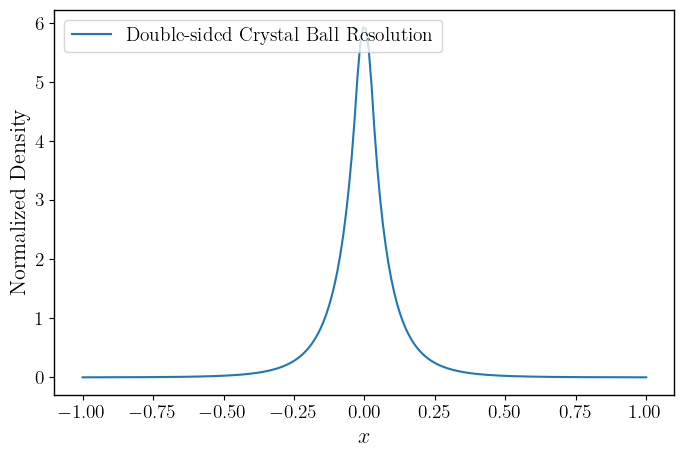

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
xvals = np.linspace(-1.0, +1.0, 200)
yvals = crystalball_double(xvals, mu_cb2, sigma_cb2, alphaL_cb2, nL_cb2, alphaR_cb2, nR_cb2) / norm_cb2
ax.plot(xvals, yvals,
        label='Double-sided Crystal Ball Resolution')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'Normalized Density')
_ = ax.legend(loc='upper left')

Set the parameters as obtained in ``efficiency_fit.ipynb``.

In [6]:
coeffs_leg = [5.53e-04, 4.90e-04, 1.58e-04, 9.74e-05]

Define the efficiency function.

In [7]:
kmin, kmax = 0.2, 2.5
# Map from k in [kmin, kmax] to z in [-1,1]
def to_minus1_1(k):
    return 2 * (k - kmin) / (kmax - kmin) - 1

# Continuous Legendre efficiency function
def epsilon_leg(k):
    z = to_minus1_1(k)
    return L.legval(z, coeffs_leg) * (2.0 / (kmax - kmin))

epsilon_leg_norm = 1.0 / (kmax - kmin) * scipy.integrate.quad(epsilon_leg, kmin, kmax)[0]
display(f"check {epsilon_leg_norm} == {coeffs_leg[0] * 2.0 / (kmax - kmin)}: difference = {epsilon_leg_norm - coeffs_leg[0] * 2.0 / (kmax - kmin)}")

# Normalized efficiency function
def epsilon_hat(k):
    return epsilon_leg(k) / (2.0 * coeffs_leg[0] / (kmax - kmin))

'check 0.00048086956521739137 == 0.0004808695652173913: difference = 5.421010862427522e-20'

Text(0, 0.5, '$\\hat{\\epsilon}(k_\\perp)$')

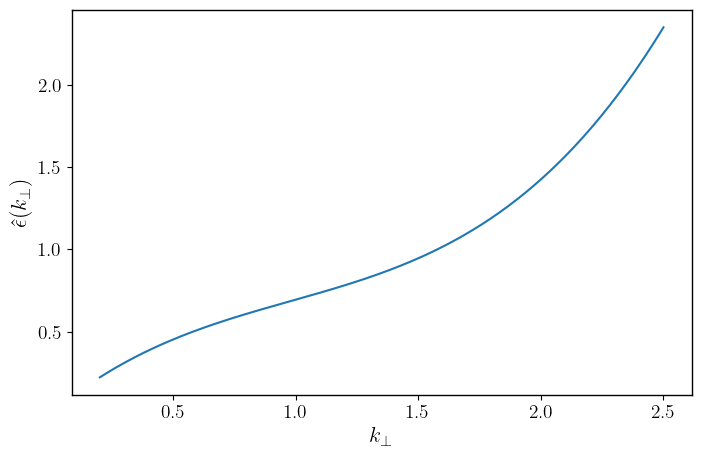

In [8]:
fig, ax = plt.subplots(figsize=(8,5))
kvals = np.linspace(kmin, kmax, 200)
evals = epsilon_hat(kvals)
ax.plot(kvals, evals,
        label='Normalized Efficiency Function')
ax.set_xlabel(r'$k_\perp$')
ax.set_ylabel(r'$\hat{\epsilon}(k_\perp)$')

Define the acceptance function.

In [9]:
def acceptance(kdet, kth):
    resolution = crystalball_double(kth - kdet, mu_cb2, sigma_cb2, alphaL_cb2, nL_cb2, alphaR_cb2, nR_cb2) / norm_cb2
    efficiency = epsilon_hat(kth)
    return resolution * efficiency

Load the best-fit point for the form factors.

In [10]:
ff_only_mode = eos.data.Mode('./data/FF-only/mode-default')

Create the differential EOS observable

In [11]:
Pth_params     = eos.Parameters()
for param, value in zip(ff_only_mode.varied_parameters, ff_only_mode.mode):
    Pth_params[param['name']].set(value)
Pth_kinematics = eos.Kinematics(**{'kperp': (kmin + kmax) / 2.0, 'kperp_min': kmin, 'kperp_max': kmax})
Pth_kperp      = Pth_kinematics['kperp']
Pth_observable = eos.Observable.make('B_s->D_slnu::dBR/dkperp', Pth_params, Pth_kinematics, eos.Options(**{'form-factors': 'BSZ2015'}))
Pth_obsnorm    = eos.Observable.make('B_s->D_slnu::BR(kperp_min,kperp_max)', Pth_params, Pth_kinematics, eos.Options(**{'form-factors': 'BSZ2015'}))
def Pth_evaluate(kperp):
    Pth_kperp.set(kperp)
    return Pth_observable.evaluate()

Interpolate the predicted $P^\text{th}(k_\perp)$

In [12]:
k_values   = np.linspace(0.0, kmax, 150)
Pth_norm   = Pth_obsnorm.evaluate()
Pth_values = [Pth_evaluate(k) / Pth_norm for k in k_values]
Pth_interp = scipy.interpolate.InterpolatedUnivariateSpline(k_values, Pth_values, k=3, ext=3)

Compare prediction and interpolation

Text(0, 0.5, '$P^\\mathrm{th}(k_\\perp)$ [GeV]$^{-1}$]')

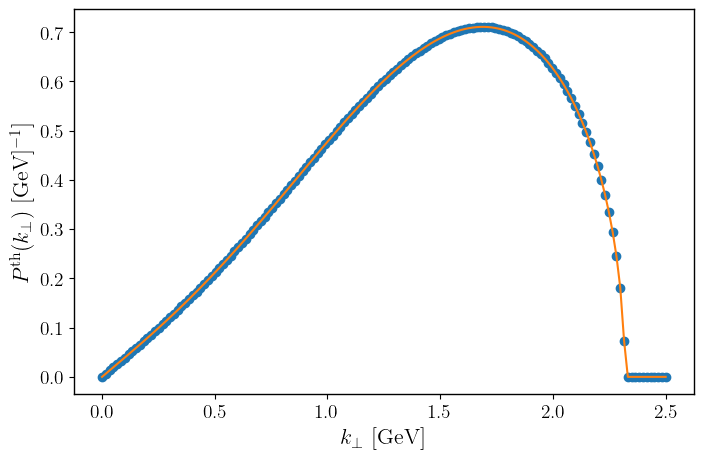

In [13]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(k_values, Pth_values, 'o', label='Computed values')
ax.plot(k_values, Pth_interp(k_values), '-', label='Spline interpolation')
ax.set_xlabel(r'$k_\perp$ [GeV]')
ax.set_ylabel(r'$P^\mathrm{th}(k_\perp)$ [GeV]$^{-1}$]')

In [14]:
MBs   = 5.36691
MDs   = 1.96835
mmu   = 0.10566
q2min = 0.0 #mmu**2
q2max = (MBs - MDs)**2

# zB: cos(theta_b)
def q2_from_kperp_and_zB(kperp, zB):
    return MBs**2 + MDs**2 - 2.0 * MBs * np.sqrt(MDs**2 + kperp**2 / (1.0 - zB**2))

def Pth_flat_integrand(zB, *args):
    kperp = args[0]
    q2 = q2_from_kperp_and_zB(kperp, zB)
    if (q2 < 0.0):
        return 0.0
    return 1.0 / ((1.0 - zB**2) * np.sqrt(MDs**2 + kperp**2 / (1.0 - zB**2)))

def Pth_flat_dblevaluate(kperp, zB):
    return MBs * kperp * Pth_flat_integrand(zB, *(kperp,)) / (q2max - q2min)

def Pth_flat_evaluate(kperp):
    integral, _ = scipy.integrate.quad(Pth_flat_integrand, -1.0, +1.0, args=(kperp,), epsabs=2.0e-5, epsrel=2.0e-5)
    return MBs * kperp * integral / (q2max - q2min)

Pth_flat_values = [Pth_flat_evaluate(k) for k in k_values]
Pth_flat_interp = scipy.interpolate.InterpolatedUnivariateSpline(k_values, Pth_flat_values, k=3, ext=3)

/tmp/ipykernel_2918061/2091075225.py:22: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral, _ = scipy.integrate.quad(Pth_flat_integrand, -1.0, +1.0, args=(kperp,), epsabs=2.0e-5, epsrel=2.0e-5)


In [15]:
integral, error = scipy.integrate.dblquad(Pth_flat_dblevaluate, -1.0, +1.0, lambda zB: 0.0, lambda zB: kmax, epsabs=2.0e-5, epsrel=2.0e-5, args=())
display(f"Check flat prediction normalization: integral = {integral} +/- {error}, difference from 1.0 = {1.0 - integral}")

'Check flat prediction normalization: integral = 1.0000022017088177 +/- 1.970396274370012e-05, difference from 1.0 = -2.201708817706205e-06'

In [16]:
integral, error = scipy.integrate.quad(lambda k: Pth_flat_interp(k), 0.0, kmax)
(1.0 - integral)

-0.00010521040263711257

Compare flat prediction and interpolation

Text(0, 0.5, '$P^\\mathrm{th}_\\mathrm{flat}(k_\\perp)$ [GeV]$^{-1}$]')

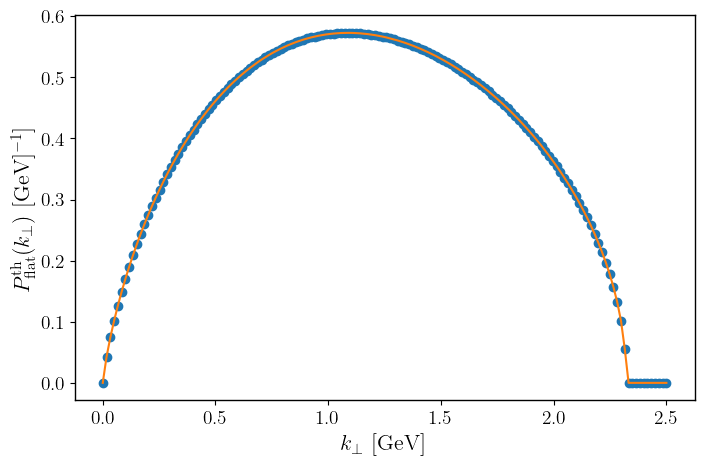

In [17]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(k_values, Pth_flat_values, 'o', label='Computed values')
ax.plot(k_values, Pth_flat_interp(k_values), '-', label='Spline interpolation')
ax.set_xlabel(r'$k_\perp$ [GeV]')
ax.set_ylabel(r'$P^\mathrm{th}_\mathrm{flat}(k_\perp)$ [GeV]$^{-1}$]')

Compare EOS prediction and flat prediction with each other

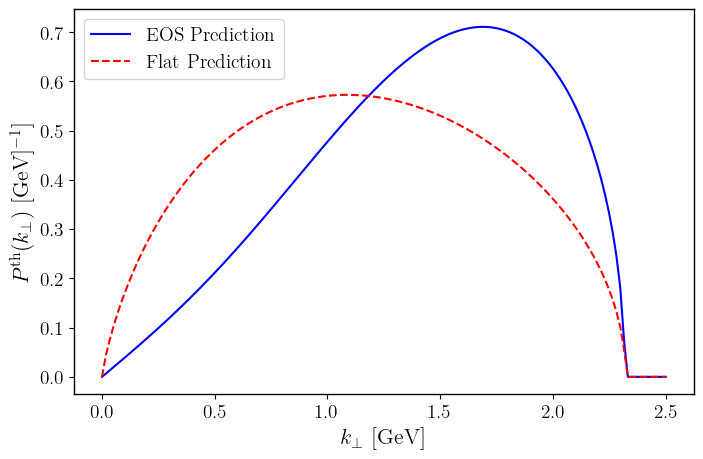

In [18]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(k_values, Pth_interp(k_values), '-', color='blue', label='EOS Prediction')
ax.plot(k_values, Pth_flat_interp(k_values), '--', color='red', label='Flat Prediction')
ax.set_xlabel(r'$k_\perp$ [GeV]')
ax.set_ylabel(r'$P^\mathrm{th}(k_\perp)$ [GeV]$^{-1}$]')
ax.legend()

# Compute Reponse Matrix

In [19]:
bin_edges = np.linspace(kmin, kmax, 21)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])
nbins = len(bin_centres)

## Compute $P^\text{th}\big|_n$ (for flat distribution in $q^2$ and a-priori distribution in $q^2$)

In [20]:
Pth_flat_bins = np.zeros((nbins,))
for n in tqdm(range(nbins), desc="Computing flat P^th|_n for each bin"):
    kth_min = bin_edges[n]
    kth_max = bin_edges[n+1]
    integral, error = scipy.integrate.quad(Pth_flat_interp, kth_min, kth_max, epsabs=1e-8, epsrel=1e-8)
    Pth_flat_bins[n] = integral

Computing flat P^th|_n for each bin: 100%|██████████| 20/20 [00:00<00:00, 4499.12it/s]


Text(0, 0.5, '$P^\\mathrm{th}_\\mathrm{flat}(k_\\perp)$ [GeV]$^{-1}$]')

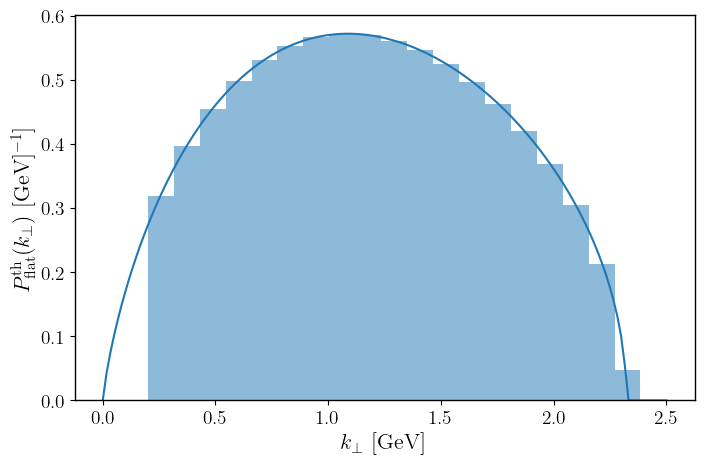

In [21]:
fig, ax = plt.subplots(figsize=(8,5))
width = (kmax - kmin) / nbins
ax.plot(k_values, Pth_flat_interp(k_values), '-', label='Spline interpolation')
ax.bar(bin_centres, Pth_flat_bins / width, width=width, alpha=0.5, label=r'$P^\mathrm{th}_\mathrm{flat}\big|_n$ per bin')
ax.set_xlabel(r'$k_\perp$ [GeV]')
ax.set_ylabel(r'$P^\mathrm{th}_\mathrm{flat}(k_\perp)$ [GeV]$^{-1}$]')

In [22]:
Pth_bins = np.zeros((nbins,))
for n in tqdm(range(nbins), desc="Computing P^th|_n for each bin"):
    kth_min = bin_edges[n]
    kth_max = bin_edges[n+1]
    integral, error = scipy.integrate.quad(Pth_interp, kth_min, kth_max, epsabs=1e-8, epsrel=1e-8)
    Pth_bins[n] = integral

Computing P^th|_n for each bin: 100%|██████████| 20/20 [00:00<00:00, 3940.72it/s]


Text(0, 0.5, '$P^\\mathrm{th}(k_\\perp)$ [GeV]$^{-1}$]')

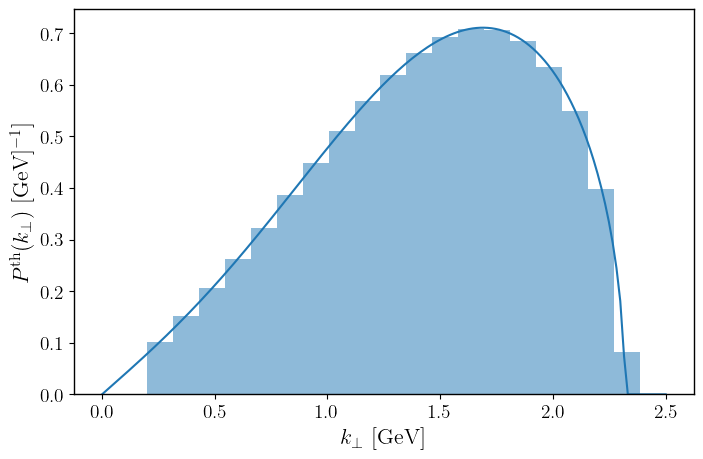

In [23]:
fig, ax = plt.subplots(figsize=(8,5))
width = (kmax - kmin) / nbins
ax.plot(k_values, Pth_interp(k_values), '-', label='Spline interpolation')
ax.bar(bin_centres, Pth_bins / width, width=width, alpha=0.5, label=r'$P^\mathrm{th}\big|_n$ per bin')
ax.set_xlabel(r'$k_\perp$ [GeV]')
ax.set_ylabel(r'$P^\mathrm{th}(k_\perp)$ [GeV]$^{-1}$]')

## Compute $P^\text{det}|_n$

In [24]:
binwidth = (kmax - kmin) / nbins
# Allocate the result matrix: rows = det bins, cols = th bins
Pdet_mn_flat = np.zeros((nbins, nbins))
for n in tqdm(range(nbins), desc="Computing partial result P^det|_n, assuming flat P^th(q^2)"):
    kth_min = bin_edges[n]
    kth_max = bin_edges[n+1]
    for m in range(nbins):
        kdet_min = bin_edges[m]
        kdet_max = bin_edges[m+1]
        # Integrate over kth and kdet
        def integrand(kth, kdet):
            accept = acceptance(kdet, kth)
            Pth    = Pth_flat_interp(kth)
            result = accept * Pth
            return result
        integral, error = scipy.integrate.dblquad(
            integrand,
            kdet_min, kdet_max,
            lambda kdet: kth_min,
            lambda kdet: kth_max,
            epsabs=1e-4,
            epsrel=1e-4
        )
        Pdet_mn_flat[m, n] = integral

R_mn_flat = np.zeros((nbins, nbins))
for m in range(nbins):
    for n in range(nbins):
        R_mn_flat[m, n] = Pdet_mn_flat[m, n] / Pth_flat_bins[n]

Computing partial result P^det|_n, assuming flat P^th(q^2): 100%|██████████| 20/20 [00:06<00:00,  2.92it/s]


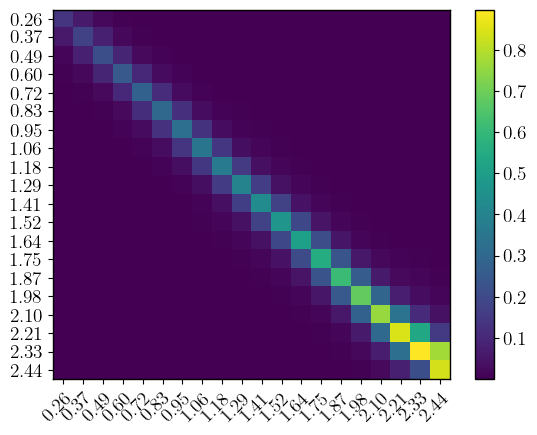

In [25]:
fig, ax = plt.subplots()
_ = ax.imshow(R_mn_flat, aspect='auto')
_ = plt.colorbar(ax.imshow(R_mn_flat, aspect='auto'), ax=ax)
_ = ax.set_xticks(range(len(bin_centres)), labels=[f"{bc:.2f}" for bc in bin_centres],
              rotation=45, ha="right", rotation_mode="anchor")
_ = ax.set_yticks(range(len(bin_centres)), labels=[f"{bc:.2f}" for bc in bin_centres])

In [26]:
# Allocate the result matrix: rows = det bins, cols = th bins
Pdet_mn_effonly = np.zeros((nbins, nbins))
for n in tqdm(range(nbins), desc="Computing partial result P^det|_n, assuming only the efficiency"):
    kth_min = bin_edges[n]
    kth_max = bin_edges[n+1]
    for m in range(nbins):
        # efficiency only -> replace resolution with delta function
        if m != n:
            continue
        kdet_min = bin_edges[m]
        kdet_max = bin_edges[m+1]
        # Integrate over kth and kdet
        def integrand(kth):
            return epsilon_hat(kth) * Pth_interp(kth)
        integral, error = scipy.integrate.quad(
            integrand,
            kth_min, kth_max,
            epsabs=1e-8,
            epsrel=1e-8
        )
        Pdet_mn_effonly[m, n] = integral

R_mn_effonly = np.zeros((nbins, nbins))
for m in range(nbins):
    for n in range(nbins):
        R_mn_effonly[m, n] = Pdet_mn_effonly[m, n] / Pth_bins[n]

Computing partial result P^det|_n, assuming only the efficiency: 100%|██████████| 20/20 [00:00<00:00, 2074.28it/s]


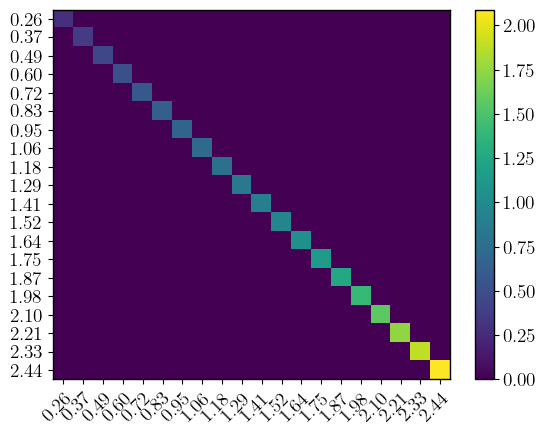

In [27]:
fig, ax = plt.subplots()
_ = ax.imshow(R_mn_effonly, aspect='auto')
_ = plt.colorbar(ax.imshow(R_mn_effonly, aspect='auto'), ax=ax)
_ = ax.set_xticks(range(len(bin_centres)), labels=[f"{bc:.2f}" for bc in bin_centres],
              rotation=45, ha="right", rotation_mode="anchor")
_ = ax.set_yticks(range(len(bin_centres)), labels=[f"{bc:.2f}" for bc in bin_centres])

In [28]:
# Allocate the result matrix: rows = det bins, cols = th bins
Pdet_mn = np.zeros((nbins, nbins))
for n in tqdm(range(nbins), desc="Computing partial results P^det|_n, assuming full acceptance"):
    kth_min = bin_edges[n]
    kth_max = bin_edges[n+1]
    for m in range(nbins):
        kdet_min = bin_edges[m]
        kdet_max = bin_edges[m+1]
        # Integrate over kth and kdet
        def integrand(kth, kdet):
            accept = acceptance(kdet, kth)
            Pth    = Pth_interp(kth)
            result = accept * Pth
            return result
        # integrates f(y, x) dy dx, where x in [a,b] and y in [g(x), h(x)]
        # so for us: x = kdet, y = kth
        integral, error = scipy.integrate.dblquad(
            integrand,
            kdet_min, kdet_max,
            lambda kdet: kth_min,
            lambda kdet: kth_max,
            epsabs=1e-4,
            epsrel=1e-4
        )
        Pdet_mn[m, n] = integral

Computing partial results P^det|_n, assuming full acceptance: 100%|██████████| 20/20 [00:06<00:00,  2.90it/s]


In [29]:
R_mn = np.zeros((nbins, nbins))
for m in range(nbins):
    for n in range(nbins):
        R_mn[m, n] = Pdet_mn[m, n] / Pth_bins[n]

Illustrate Response Matrix

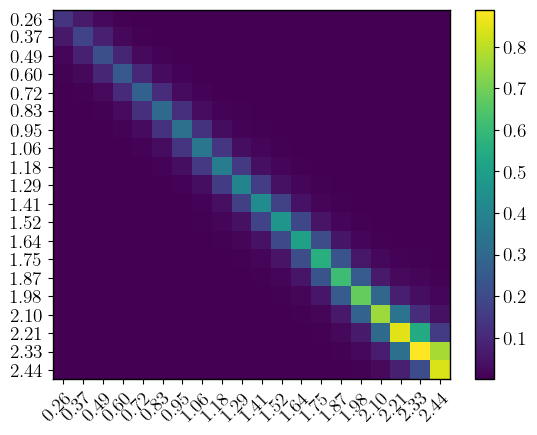

In [30]:
fig, ax = plt.subplots()
_ = ax.imshow(R_mn, aspect='auto')
_ = plt.colorbar(ax.imshow(R_mn, aspect='auto'), ax=ax)
_ = ax.set_xticks(range(len(bin_centres)), labels=[f"{bc:.2f}" for bc in bin_centres],
              rotation=45, ha="right", rotation_mode="anchor")
_ = ax.set_yticks(range(len(bin_centres)), labels=[f"{bc:.2f}" for bc in bin_centres])

# Check result and save it

In [31]:
eigvals_flat    = np.linalg.eigvals(R_mn_flat)
eigvals_effonly = np.linalg.eigvals(R_mn_effonly)
eigvals         = np.linalg.eigvals(R_mn)

In [32]:
display(eigvals_flat)
display(eigvals_effonly)
display(eigvals)

array([1.62903707, 1.14250352, 0.91216041, 0.76996114, 0.66908541,
       0.58871658, 0.51979437, 0.45896579, 0.07550904, 0.40519598,
       0.10699702, 0.35829002, 0.13137379, 0.15459681, 0.17902087,
       0.2053141 , 0.23343222, 0.26199102, 0.28856239, 0.31893487])

array([0.27884657, 0.36958892, 0.44719599, 0.51387623, 0.57212144,
       0.62450753, 0.67364096, 0.72214061, 0.77263083, 0.82773715,
       0.89008603, 0.96230075, 1.04699791, 1.14677943, 1.2642106 ,
       1.40175735, 1.56151392, 1.74299655, 1.89312143, 2.08898698])

array([1.6282186 , 1.14102958, 0.91128169, 0.76970638, 0.66928934,
       0.58912188, 0.52016112, 0.4591589 , 0.07568861, 0.40515671,
       0.10711237, 0.35795355, 0.13145141, 0.15467004, 0.17910099,
       0.20539712, 0.2334672 , 0.26165947, 0.2875238 , 0.31814729])

In [33]:
determinant_flat    = np.linalg.det(R_mn_flat)
determinant_effonly = np.linalg.det(R_mn_effonly)
determinant         = np.linalg.det(R_mn)

In [34]:
display(determinant_flat)
display(determinant_effonly)
display(determinant)

np.float64(6.053678189449188e-10)

np.float64(0.05164148268321392)

np.float64(6.030527772654775e-10)

In [35]:
np.savez('output/response_matrix_flat.npz', R_mn_flat)
np.savez('output/response_matrix_effonly.npz', R_mn_effonly)
np.savez('output/response_matrix.npz', R_mn)

In [36]:
print(('# Response Matrix R_mn (full acceptance)'))
for m in range(nbins):
    row = '- [ '
    row += ', '.join([f"{c:.3e}" for c in R_mn[m, :]])
    row += ' ]'
    print(row)

# Response Matrix R_mn (full acceptance)
- [ 1.348e-01, 6.340e-02, 1.752e-02, 6.058e-03, 2.453e-03, 1.117e-03, 5.582e-04, 3.006e-04, 1.726e-04, 1.048e-04, 6.684e-05, 4.455e-05, 3.090e-05, 2.222e-05, 1.650e-05, 1.261e-05, 9.893e-06, 7.962e-06, 6.852e-06, 6.003e-06 ]
- [ 6.147e-02, 1.790e-01, 7.818e-02, 2.032e-02, 6.781e-03, 2.687e-03, 1.208e-03, 5.993e-04, 3.220e-04, 1.851e-04, 1.128e-04, 7.231e-05, 4.851e-05, 3.387e-05, 2.452e-05, 1.832e-05, 1.409e-05, 1.114e-05, 9.470e-06, 7.954e-06 ]
- [ 1.415e-02, 7.906e-02, 2.167e-01, 9.089e-02, 2.277e-02, 7.431e-03, 2.906e-03, 1.297e-03, 6.420e-04, 3.453e-04, 1.992e-04, 1.220e-04, 7.873e-05, 5.317e-05, 3.738e-05, 2.723e-05, 2.047e-05, 1.587e-05, 1.331e-05, 1.102e-05 ]
- [ 4.153e-03, 1.829e-02, 9.412e-02, 2.491e-01, 1.020e-01, 2.497e-02, 8.039e-03, 3.121e-03, 1.390e-03, 6.885e-04, 3.717e-04, 2.155e-04, 1.328e-04, 8.630e-05, 5.868e-05, 4.152e-05, 3.043e-05, 2.307e-05, 1.906e-05, 1.553e-05 ]
- [ 1.451e-03, 5.384e-03, 2.182e-02, 1.071e-01, 2.774e-01, 

In [37]:
print(('# Response Matrix R_mn (full acceptance)'))
for m in range(nbins):
    row = '- [ '
    row += ', '.join([f"{c:.3e}" for c in R_mn_flat[m, :]])
    row += ' ]'
    print(row)

# Response Matrix R_mn (full acceptance)
- [ 1.343e-01, 6.467e-02, 1.779e-02, 6.131e-03, 2.478e-03, 1.127e-03, 5.619e-04, 3.023e-04, 1.734e-04, 1.052e-04, 6.705e-05, 4.467e-05, 3.097e-05, 2.226e-05, 1.652e-05, 1.262e-05, 9.901e-06, 7.965e-06, 6.837e-06, 6.003e-06 ]
- [ 5.975e-02, 1.786e-01, 7.969e-02, 2.062e-02, 6.860e-03, 2.712e-03, 1.217e-03, 6.030e-04, 3.237e-04, 1.859e-04, 1.132e-04, 7.251e-05, 4.862e-05, 3.394e-05, 2.456e-05, 1.834e-05, 1.410e-05, 1.114e-05, 9.447e-06, 7.954e-06 ]
- [ 1.381e-02, 7.721e-02, 2.164e-01, 9.258e-02, 2.309e-02, 7.513e-03, 2.932e-03, 1.307e-03, 6.457e-04, 3.470e-04, 2.000e-04, 1.224e-04, 7.893e-05, 5.328e-05, 3.744e-05, 2.727e-05, 2.049e-05, 1.588e-05, 1.327e-05, 1.102e-05 ]
- [ 4.061e-03, 1.791e-02, 9.213e-02, 2.489e-01, 1.038e-01, 2.531e-02, 8.123e-03, 3.147e-03, 1.399e-03, 6.922e-04, 3.733e-04, 2.163e-04, 1.332e-04, 8.650e-05, 5.879e-05, 4.158e-05, 3.046e-05, 2.308e-05, 1.900e-05, 1.553e-05 ]
- [ 1.422e-03, 5.287e-03, 2.143e-02, 1.050e-01, 2.772e-01, 